Consider the finite problem defined as:

\begin{equation}
-\frac{\hbar^2}{2m} \frac{d^2  \psi}{dx^2}  + V(x) \psi =  E \psi
\end{equation}

where

*   $\hbar $ is the reduced Planck's constant
*   $m$ is the mass of particle
*  $\psi $ is the wavefunction (representing the eigenfunction/ eigenstate)
* $V(x) $ is the potential energy of the particle at any point $x
* $E$ is the energy of the particle (representing the eigenvalue of the equation)

In this notebook we will consider the solution in higher dimensions.

In [1]:
#Importing the required libraries
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.autograd import grad
from torch import Tensor
import torch.nn as nn
import torch.optim as optim     #optimizer
import time
import copy
import pandas as pd  #for the moving average
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau

torch.manual_seed(1234)

np.random.seed(1234)

#Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(device)

if device.type == 'cuda':
  print(torch.cuda.get_device_name(0))

from pyDOE import lhs #latin hypercube sampling

cuda
NVIDIA RTX A6000


In [246]:
#Second derivatives from Automatic Differentiation
#Compute the Laplacian i.e sum of s2nd derivatives across the dimensions
def laplacian(f,x):
  laplace = []
  for i in range(f.shape[1]):
    u_x = grad(f[:,i], x, grad_outputs=torch.ones_like(f[:,i]), create_graph=True, retain_graph = True)[0]
    u_xx = grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True, retain_graph = True)[0]
    laplace.append(u_xx.sum(dim=1, keepdim=True)) #Sum the 2nd derivatives across the dimensions
  laplace = torch.cat(laplace, dim=1)
  return laplace

In [247]:
#Defining the hyperparameters
class config:
  def __init__(self):
    self.t0 = -10
    self.tf = 10
    self.xbc = 0
    self.D = 2
    self.lower_bound = self.t0 * torch.ones(self.D).float()
    self.upper_bound = self.tf * torch.ones(self.D).float()
    self.vol = torch.prod(self.upper_bound - self.lower_bound)    # scalar volume of the domain
    self.eig_num = 5
    self.col_pts = 500
    self.layers = [self.D,100,100, 100,self.eig_num]
    self.epochs = 20000

cfg = config()

In [248]:
#Defining the Parametric Solution
#This enforces the solution on the boundaries
def parametricSolutions(t, nn, cfg):
    N1 = nn(t)                                    # (batch, K)
    # compute both factors for each column, then take their product
    f = ((1 - torch.exp(-(t - cfg.t0))) * (1 - torch.exp(  t - cfg.tf))) # → (batch, dim)
    f = f.prod(dim=1, keepdim=True)   # → (batch, 1)
    psi_hat = cfg.xbc + f * N1        # broadcast (batch,1)*(batch,K)
    return psi_hat

In [249]:
#Training points
x_lhs = cfg.lower_bound + (cfg.upper_bound - cfg.lower_bound) * torch.tensor(lhs(cfg.D, cfg.col_pts)).float()

In [250]:
def hamEqs_Loss(psi, laplace, v): #Defines the PDE loss
    # Hamiltonian applied to psi
    hamEqs = -0.5 * laplace + v * psi
    #Multi carlo integration
    numerator = cfg.vol * (psi * hamEqs).mean(dim = 0)
    denominator = cfg.vol * (psi * psi).mean(dim = 0)
    E = numerator / denominator
    # Residual (Schrödinger equation)
    res = 0.5 *laplace + (E - v) * psi

    return res, E

In [251]:
#The Harmonic potential
def pot(t):
    return 0.5 * (t.pow(2).sum(dim=1, keepdim=True))

In [252]:
V = pot(x_lhs).view(-1,1)
V.shape

torch.Size([500, 1])

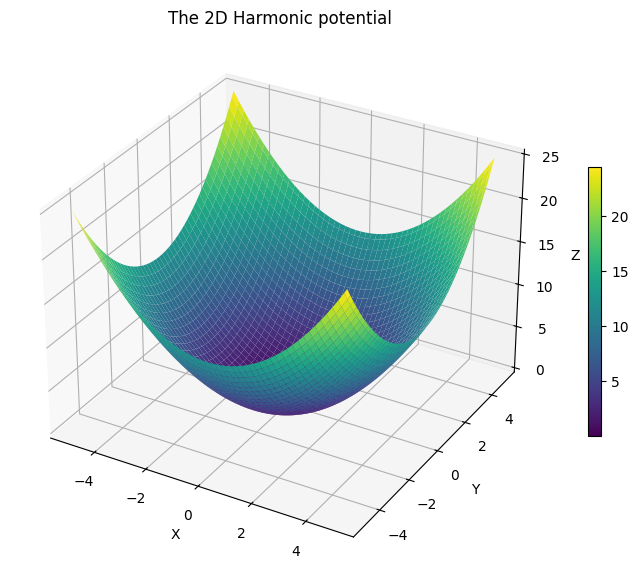

In [253]:
#Plotting the Potential
from mpl_toolkits.mplot3d import Axes3D   # registers the 3D projection

# Example data
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)
Z = 0.5 * (X**2 + Y**2)
#x_sq = X**2 + Y**2
#Z = np.exp(-x_sq)

# Build the figure & 3D subplot
fig = plt.figure(figsize=(10,7))
ax  = fig.add_subplot(111, projection='3d')

# Draw the surface
surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')

# Add colorbar, labels, etc.
fig.colorbar(surf, shrink=0.5)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('The 2D Harmonic potential')

plt.show()


In [254]:
#Defining the Frobenius norm
def frobenius_norm(G):
    I = torch.eye(G.shape[0], device = device, dtype = G.dtype)
    loss = torch.linalg.matrix_norm(G - I) #The frobenius norm
    return loss

#Defining the monotonicity_penalty, this is to ensure that the eigenpairs are learned monotonically
def monotonicity_penalty(E, margin = 0.0):
    diffs = E[:-1] - E[1:] + margin
    penalty = torch.relu(diffs).sum()    #torch.where(diffs > 0, torch.zeros_like(diffs), torch.exp(-diffs)).sum()       #
    return penalty

#Defining the cosine matrix
def cosine_matrix(psi,x):
  psi_norm = torch.sqrt(cfg.vol * (psi * psi).mean(dim = 0))  # (k,)
  psi_normalized = psi / psi_norm  # (n, k)
  psi_prod = psi_normalized.unsqueeze(2) * psi_normalized.unsqueeze(1)  # (n, k, k)
  cos_matrix = cfg.vol * psi_prod.mean(dim=0)   # → (K, K)
  return cos_matrix

#Norm loss to ensure the wavefunctions are properly scaled
def norm_loss(psi,x,cfg):
  psi_norm = torch.sqrt(cfg.vol * (psi * psi).mean(dim = 0))  # (k,)
  scale_term = (cfg.tf - cfg.t0)*psi_norm/cfg.col_pts
  return torch.sum((1-scale_term).pow(2))

In [255]:
#Defining the NN architecture without symmetry
class qNN(torch.nn.Module):
  def __init__(self,cfg):
    super(qNN,self).__init__()
    self.activation = torch.sin
    self.layers = cfg.layers

    #Defining the Layers
    self.linears = nn.ModuleList([nn.Linear(self.layers[i], self.layers[i+1]) for i in range(len(self.layers) - 1)])

    #Initializing the weights
    for i in range(len(self.layers)-1):
      nn.init.xavier_normal_(self.linears[i].weight.data, gain=1.0)
      nn.init.zeros_(self.linears[i].bias.data)

  #Defining the forward pass
  def forward(self,x):
    if torch.is_tensor(x) != True:
      x = torch.from_numpy(x)
    a = x.float()
    #In1 = self.ein(torch.ones_like(a))
    for i in range(len(self.linears)-1):
      z = self.linears[i](a)
      #a = self.activation(z)
      if i == 0:
        a = self.activation(20*z) #Multiplying the input by a weight as recommended by the paper SIREN
      else:
        a = self.activation(z)
    a = self.linears[-1](a)
    return a

### Pre-Trainer

In [256]:
def fg(x, s):
  """Batch of Gaussians for different widths."""
  return torch.exp(-x.pow(2).sum(dim=1, keepdim=True)/ (s.unsqueeze(0)) ** 2)  # (n_points, n_functions)

N_max = cfg.eig_num
pn = torch.arange(1,N_max+1).to(device) #Sequence from 1 to number of eigenvalues
pn.unsqueeze(0).shape

torch.Size([1, 5])

### Learning Rate Finder

In [257]:
#We want to find the best lr for our defined model
model_lr = qNN(cfg).to(device)
optimizer_lr = optim.Adam(model_lr.parameters(), lr=1e-7)

In [258]:
def common_train_step(NN,t_rand,vx, cfg):
    #Getting the parametric solution
    psi =parametricSolutions(t_rand,NN,cfg) #The forward pass
    psi = psi.to(device)

    # Compute second derivatives
    psi_xx = laplacian(psi,t_rand)

    L,E = hamEqs_Loss(psi,psi_xx,vx)
    Loss = torch.nn.MSELoss()
    #Getting the losses after each forward pass
    pde_loss = Loss(L,torch.zeros_like(L))  #The scaled pde_loss
    n_loss = norm_loss(psi,t_rand,cfg)
    G = cosine_matrix(psi, t_rand)
    cosine_loss = frobenius_norm(G)
    return pde_loss, n_loss, cosine_loss, E

In [259]:
losses = []
lrs = []

#Sorting and unsorting here
# Sort only the coordinates, without gradients

x_lhs = x_lhs.to(device)
x_lhs.requires_grad = True
vx = pot(x_lhs).to(device)

start_lr = 1e-7
end_lr = 0.01
num_iter = 100
lr_mult = (end_lr / start_lr) ** (1/num_iter)

lr = start_lr

for iteration in range(num_iter):
    optimizer_lr.param_groups[0]['lr'] = lr

    optimizer_lr.zero_grad()
    pde_loss, n_loss, cosine_loss,En= common_train_step(model_lr,x_lhs,vx,cfg)
    monotone_loss =monotonicity_penalty(En, margin = 0.1)
    loss = pde_loss + n_loss+ cosine_loss + monotone_loss
    loss.backward()

    optimizer_lr.step()

    lrs.append(lr)
    losses.append(loss.item())

    lr *= lr_mult  # increase learning rate exponentially

# Plot the result
plt.plot(lrs, losses)
plt.xscale('log')
plt.axvline(x=5e-5, color='red', linestyle='--')
plt.xlabel('Learning Rate')
plt.ylabel('Loss')
plt.title('LR Range Test')
plt.show()

RuntimeError: Trying to backward through the graph a second time (or directly access saved tensors after they have already been freed). Saved intermediate values of the graph are freed when you call .backward() or autograd.grad(). Specify retain_graph=True if you need to backward through the graph a second time or if you need to access saved tensors after calling backward.